
# Oracle-Guided Neural Contextual Bandit — Smart EW Scheduler

This notebook replaces the previous disjoint LinUCB implementation with the final scheduler architecture:

**GRU temporal encoder → action-conditioned neural value model → bootstrapped ensemble → Thompson Sampling**

The Oracle is used as **privileged offline supervision only after a complete RF environment has finished**.

During an actual scan episode the scheduler receives only:
- its recursive belief state,
- its own observable scan history,
- the selected-band hit/miss,
- time/history features.

The Oracle schedule is revealed only after the episode and is then used to create expert demonstrations for the next training update.

The recursive belief model is treated as frozen and already validated. This notebook focuses on the scheduler/bandit.



## Training architecture

### Online deployment

```text
RF environment
      │
      ▼
partial observation
      │
      ▼
frozen recursive belief model
      │
      ▼
belief/history sequence
      │
      ▼
GRU temporal encoder
      │
      ▼
latent state
      │
      ▼
action-conditioned Q(s, band)
      │
      ▼
5-head bootstrap ensemble
      │
      ▼
Thompson Sampling
      │
      ▼
selected frequency band
      │
      ▼
hit / miss
      │
      └──────────────► next belief/state
```

### After an entire environment finishes

```text
complete trajectory from our scheduler
              │
              ▼
        episode ends
              │
              ▼
       reveal saved Oracle
              │
              ▼
(state seen by scheduler, Oracle action)
              │
              ▼
      expert replay buffer
              │
              ▼
neural bandit update
```

This prevents future RF truth or Oracle actions from influencing a decision **inside the episode**.


In [1]:

# ============================================================
# 1. IMPORTS
# ============================================================

from pathlib import Path
from collections import deque
import math
import random
import json

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)


NumPy: 2.2.6
PyTorch: 2.3.1


In [2]:

# ============================================================
# 2. CONFIGURATION
# ============================================================

# Project directories
TRAIN_RFENV_DIR = Path("./train_RFEnvs")
VAL_RFENV_DIR = Path("./val_RFEnvs")
ORACLE_DIR = Path("./Oracle")
TRAIN_FINAL_DIR = Path("./train_final")

TRAIN_FINAL_DIR.mkdir(parents=True, exist_ok=True)

# RF representation
FREQ_MIN_MHZ = 0
FREQ_MAX_MHZ = 18_000
FREQ_BIN_MHZ = 500
TIME_BIN_S = 0.050

N_FREQ_BINS = int(
    (FREQ_MAX_MHZ - FREQ_MIN_MHZ) / FREQ_BIN_MHZ
)

assert N_FREQ_BINS == 36

# Frozen recursive-model checkpoint
RECURSIVE_MODEL_PATH = (
    TRAIN_FINAL_DIR / "recursive_belief_updater.pt"
)

# Neural bandit checkpoint
BANDIT_CHECKPOINT_PATH = (
    TRAIN_FINAL_DIR / "neural_oracle_bandit.pt"
)

# Temporal state
SEQUENCE_LENGTH = 12

# State:
#   belief                36
#   scan age              36
#   rolling hit rate      36
#   time since hit        36
#   last observation      36
#   scan count            36
#   previous action       36
#   time sin/cos            2
STATE_DIM = (
    7 * N_FREQ_BINS
    + 2
)

# Candidate/action features:
#   belief, age, hit rate, time since hit,
#   last observation, scan count, band position
CANDIDATE_DIM = 7

# Neural architecture
GRU_HIDDEN_DIM = 128
ACTION_EMBED_DIM = 16
Q_HIDDEN_DIM = 128
N_BOOTSTRAP_HEADS = 5

# Training
SEED = 42
BATCH_SIZE = 128
REPLAY_CAPACITY = 20_000
TRAIN_UPDATES_PER_EPISODE = 4
MIN_REPLAY_TO_TRAIN = 256

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0

# Bootstrap inclusion probability
BOOTSTRAP_PROB = 0.8

# Oracle distillation
ORACLE_LOSS_WEIGHT_START = 2.0
ORACLE_LOSS_WEIGHT_END = 0.25
ORACLE_DECAY_EPISODES = 500

# Exploration / coverage
INITIAL_SWEEP = True
MAX_SCAN_GAP_STEPS = 40

# "per_step" = sample a head every action.
# "per_episode" = sample one head for the whole episode.
THOMPSON_MODE = "per_step"

# Reward knobs.
# The architecture is independent of the exact reward design.
REWARD_HIT_WEIGHT = 1.0
REWARD_MISS_WEIGHT = 0.0
REWARD_NEW_BAND_WEIGHT = 0.0
REWARD_STALE_HIT_WEIGHT = 0.0
REWARD_INFORMATION_GAIN_WEIGHT = 0.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Number of bands:", N_FREQ_BINS)
print("State dimension:", STATE_DIM)
print("Candidate dimension:", CANDIDATE_DIM)


Device: cuda
Number of bands: 36
State dimension: 254
Candidate dimension: 7


In [3]:

# ============================================================
# 3. LOAD RF ENVIRONMENTS
# ============================================================

def list_rf_environments(directory):
    directory = Path(directory)

    files = sorted(
        p for p in directory.glob("*.npy")
        if p.name != "environment_config.npy"
    )

    if not files:
        raise FileNotFoundError(
            f"No RF environments found in {directory.resolve()}"
        )

    return files


rf_files = list_rf_environments(
    TRAIN_RFENV_DIR
)

print(
    f"Found {len(rf_files)} training RF environments."
)

print(
    "First environment:",
    rf_files[0].name
)


Found 5 training RF environments.
First environment: config_0.npy


In [4]:

# ============================================================
# 4. TRANSMISSION EVENT EXTRACTION
# ============================================================

def extract_transmission_events(env):
    """
    A transmission event is a continuous run of 1s
    in one frequency band.
    """

    env = np.asarray(env)

    if env.ndim != 2:
        raise ValueError(
            f"Expected 2-D environment, got {env.shape}"
        )

    if env.shape[1] != N_FREQ_BINS:
        raise ValueError(
            f"Expected {N_FREQ_BINS} bands, got {env.shape[1]}"
        )

    events = []
    event_id = 0
    n_time_steps = len(env)

    for band in range(N_FREQ_BINS):

        in_event = False
        start = None

        for t in range(n_time_steps):

            active = bool(env[t, band] > 0)

            if active and not in_event:
                start = t
                in_event = True

            elif not active and in_event:

                end = t - 1

                events.append({
                    "id": event_id,
                    "band": band,
                    "start": start,
                    "end": end,
                    "duration": end - start + 1,
                })

                event_id += 1
                in_event = False

        if in_event:

            end = n_time_steps - 1

            events.append({
                "id": event_id,
                "band": band,
                "start": start,
                "end": end,
                "duration": end - start + 1,
            })

            event_id += 1

    events.sort(
        key=lambda e: (e["start"], e["band"])
    )

    for new_id, event in enumerate(events):
        event["id"] = new_id

    return events


def build_event_lookup(
    events,
    n_time_steps
):

    active_events = [
        [] for _ in range(n_time_steps)
    ]

    for event in events:

        for t in range(
            event["start"],
            event["end"] + 1
        ):

            active_events[t].append(
                event["id"]
            )

    return active_events



## 5. Online information boundary

The policy never receives the RF row except at the single selected band.

The full `env` is used only by the simulator to:
1. produce the selected-band observation,
2. calculate offline interception metrics.

The Oracle schedule is not loaded inside the online action-selection loop.


In [5]:

# ============================================================
# 6. LOAD THE FROZEN RECURSIVE BELIEF MODEL
# ============================================================

class BeliefUpdater(nn.Module):

    def __init__(
        self,
        n_bands=36,
        hidden_size=128
    ):

        super().__init__()

        self.n_bands = n_bands

        input_size = (
            n_bands
            + n_bands
            + 1
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                hidden_size
            ),
            nn.ReLU(),

            nn.Linear(
                hidden_size,
                hidden_size
            ),
            nn.ReLU(),

            nn.Linear(
                hidden_size,
                n_bands
            )
        )

    def forward(
        self,
        probabilities,
        actions,
        observations
    ):

        action_one_hot = torch.zeros(
            actions.shape[0],
            self.n_bands,
            device=actions.device
        )

        action_one_hot.scatter_(
            1,
            actions.unsqueeze(1),
            1.0
        )

        observations = (
            observations
            .float()
            .unsqueeze(1)
        )

        x = torch.cat(
            [
                probabilities,
                action_one_hot,
                observations
            ],
            dim=1
        )

        return self.network(x)


checkpoint = torch.load(
    RECURSIVE_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

loaded_config = checkpoint[
    "model_config"
]

recursive_model = BeliefUpdater(
    n_bands=loaded_config[
        "n_freq_bins"
    ],
    hidden_size=loaded_config[
        "hidden_size"
    ]
).to(DEVICE)

recursive_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

recursive_model.eval()

for parameter in recursive_model.parameters():
    parameter.requires_grad = False

P_baseline = checkpoint[
    "P_baseline"
].astype(np.float32)

assert len(P_baseline) == N_FREQ_BINS

print("✓ Frozen recursive belief model loaded.")
print("Checkpoint:", RECURSIVE_MODEL_PATH)
print("Baseline shape:", P_baseline.shape)


✓ Frozen recursive belief model loaded.
Checkpoint: train_final\recursive_belief_updater.pt
Baseline shape: (36,)


In [6]:

# ============================================================
# 7. RECURSIVE BELIEF PROVIDER
# ============================================================

class RecursiveBeliefProvider:

    def __init__(
        self,
        model,
        baseline,
        device
    ):

        self.model = model
        self.baseline = np.asarray(
            baseline,
            dtype=np.float32
        )
        self.device = device

        self.reset()

    def reset(self):

        self.belief = torch.tensor(
            self.baseline,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

    def __call__(
        self,
        t,
        action,
        observation
    ):

        if action is None:

            return (
                self.belief
                .squeeze(0)
                .detach()
                .cpu()
                .numpy()
                .copy()
            )

        action_tensor = torch.tensor(
            [action],
            dtype=torch.long,
            device=self.device
        )

        observation_tensor = torch.tensor(
            [observation],
            dtype=torch.float32,
            device=self.device
        )

        with torch.no_grad():

            logits = self.model(
                self.belief,
                action_tensor,
                observation_tensor
            )

            self.belief = torch.sigmoid(
                logits
            )

        return (
            self.belief
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
            .copy()
        )


belief_provider = RecursiveBeliefProvider(
    model=recursive_model,
    baseline=P_baseline,
    device=DEVICE
)

print("✓ Recursive belief provider ready.")


✓ Recursive belief provider ready.



# 8. Observable scheduler state

For every band the scheduler maintains:

- current recursive belief
- age since last scan
- rolling hit rate
- time since last observed hit
- last observed value
- scan count

Global/temporal information:

- previous action
- sinusoidal/cosine time encoding

A sequence of these states is passed to a GRU so the scheduler can learn temporal patterns rather than reacting only to one instantaneous probability vector.


In [7]:

# ============================================================
# 9. SCHEDULER MEMORY
# ============================================================

class SchedulerMemory:

    def __init__(
        self,
        n_bands=N_FREQ_BINS,
        hit_memory=10
    ):

        self.n_bands = n_bands
        self.hit_memory = hit_memory

        self.reset()

    def reset(self):

        self.scan_counts = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.hit_counts = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.age_since_scan = np.full(
            self.n_bands,
            np.inf,
            dtype=np.float32
        )

        self.time_since_hit = np.full(
            self.n_bands,
            np.inf,
            dtype=np.float32
        )

        self.last_observation = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.recent_observations = [
            deque(maxlen=self.hit_memory)
            for _ in range(self.n_bands)
        ]

        self.previous_action = -1
        self.step = 0

    def _normalized_age(self, values):

        values = np.asarray(
            values,
            dtype=np.float32
        )

        finite = np.isfinite(values)

        clipped = np.where(
            finite,
            np.minimum(
                values,
                float(MAX_SCAN_GAP_STEPS)
            ),
            float(MAX_SCAN_GAP_STEPS)
        )

        return (
            clipped
            / float(MAX_SCAN_GAP_STEPS)
        ).astype(np.float32)

    def hit_rates(self):

        rates = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        for band in range(self.n_bands):

            history = (
                self.recent_observations[
                    band
                ]
            )

            if history:

                rates[band] = (
                    float(sum(history))
                    / float(len(history))
                )

        return rates

    def state_vector(self, belief):

        belief = np.asarray(
            belief,
            dtype=np.float32
        )

        if belief.shape != (
            self.n_bands,
        ):

            raise ValueError(
                f"Expected belief shape "
                f"({self.n_bands},), "
                f"got {belief.shape}"
            )

        age = self._normalized_age(
            self.age_since_scan
        )

        time_since_hit = (
            self._normalized_age(
                self.time_since_hit
            )
        )

        hit_rates = self.hit_rates()

        scan_count = (
            np.log1p(
                self.scan_counts
            )
            / np.log1p(50.0)
        )

        scan_count = np.clip(
            scan_count,
            0.0,
            1.0
        )

        previous_action = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        if (
            0
            <= self.previous_action
            < self.n_bands
        ):

            previous_action[
                self.previous_action
            ] = 1.0

        phase = (
            2.0
            * np.pi
            * self.step
            / 200.0
        )

        time_features = np.asarray(
            [
                np.sin(phase),
                np.cos(phase),
            ],
            dtype=np.float32
        )

        state = np.concatenate(
            [
                belief,
                age,
                hit_rates,
                time_since_hit,
                self.last_observation,
                scan_count,
                previous_action,
                time_features,
            ]
        ).astype(np.float32)

        if len(state) != STATE_DIM:

            raise RuntimeError(
                f"State dimension mismatch: "
                f"{len(state)} != {STATE_DIM}"
            )

        return state

    def candidate_features(
        self,
        belief
    ):

        belief = np.asarray(
            belief,
            dtype=np.float32
        )

        age = self._normalized_age(
            self.age_since_scan
        )

        time_since_hit = (
            self._normalized_age(
                self.time_since_hit
            )
        )

        hit_rates = self.hit_rates()

        scan_count = (
            np.log1p(
                self.scan_counts
            )
            / np.log1p(50.0)
        )

        scan_count = np.clip(
            scan_count,
            0.0,
            1.0
        )

        band_position = (
            np.arange(
                self.n_bands,
                dtype=np.float32
            )
            / max(
                self.n_bands - 1,
                1
            )
        )

        features = np.stack(
            [
                belief,
                age,
                hit_rates,
                time_since_hit,
                self.last_observation,
                scan_count,
                band_position,
            ],
            axis=1
        ).astype(np.float32)

        assert features.shape == (
            self.n_bands,
            CANDIDATE_DIM
        )

        return features

    def reward_context(
        self,
        action
    ):

        age = self.age_since_scan[
            action
        ]

        stale_age = (
            float(MAX_SCAN_GAP_STEPS)
            if not np.isfinite(age)
            else float(age)
        )

        is_new_band_hit = (
            self.scan_counts[action] > 0
            and self.hit_counts[action] > 0
        )

        return {
            "age": stale_age,

            "time_since_hit": (
                float(MAX_SCAN_GAP_STEPS)
                if not np.isfinite(
                    self.time_since_hit[action]
                )
                else float(
                    self.time_since_hit[action]
                )
            ),

            "is_new_band_hit":
                bool(is_new_band_hit),
        }

    def update(
        self,
        action,
        observation
    ):

        hit = int(
            observation > 0
        )

        self.age_since_scan += 1

        finite_hit_age = np.isfinite(
            self.time_since_hit
        )

        self.time_since_hit[
            finite_hit_age
        ] += 1

        self.age_since_scan[
            action
        ] = 0

        self.scan_counts[
            action
        ] += 1

        self.hit_counts[
            action
        ] += hit

        self.last_observation[
            action
        ] = hit

        self.recent_observations[
            action
        ].append(hit)

        if hit:
            self.time_since_hit[
                action
            ] = 0

        self.previous_action = int(
            action
        )

        self.step += 1


In [8]:

# ============================================================
# 10. TEMPORAL STATE BUILDER
# ============================================================

class TemporalStateBuilder:

    def __init__(
        self,
        n_bands=N_FREQ_BINS,
        sequence_length=SEQUENCE_LENGTH
    ):

        self.n_bands = n_bands
        self.sequence_length = sequence_length

        self.memory = SchedulerMemory(
            n_bands=n_bands
        )

        self.history = deque(
            maxlen=sequence_length
        )

    def reset(self):

        self.memory.reset()
        self.history.clear()

    def observe_state(
        self,
        belief
    ):

        state = self.memory.state_vector(
            belief
        )

        candidate = (
            self.memory.candidate_features(
                belief
            )
        )

        self.history.append(
            state.copy()
        )

        sequence = list(
            self.history
        )

        if len(sequence) < (
            self.sequence_length
        ):

            first = sequence[0]

            padding = [
                first.copy()
                for _ in range(
                    self.sequence_length
                    - len(sequence)
                )
            ]

            sequence = (
                padding
                + sequence
            )

        sequence = np.stack(
            sequence,
            axis=0
        ).astype(np.float32)

        assert sequence.shape == (
            self.sequence_length,
            STATE_DIM
        )

        return sequence, candidate

    def update(
        self,
        action,
        observation
    ):

        self.memory.update(
            action,
            observation
        )

    def reward_context(
        self,
        action
    ):

        return self.memory.reward_context(
            action
        )



# 11. Neural action-value model

Each model head estimates:

\[
Q_\theta(s_t,a)
\]

using:
1. a GRU over recent scheduler states,
2. an embedding for the candidate frequency band,
3. candidate-specific observable features,
4. a nonlinear MLP value head.

The model is shared across frequency bands rather than maintaining 36 independent linear reward models.


In [9]:

# ============================================================
# 12. SINGLE NEURAL BANDIT HEAD
# ============================================================

class NeuralBanditHead(nn.Module):

    def __init__(
        self,
        state_dim=STATE_DIM,
        n_bands=N_FREQ_BINS,
        candidate_dim=CANDIDATE_DIM,
        gru_hidden_dim=GRU_HIDDEN_DIM,
        action_embed_dim=ACTION_EMBED_DIM,
        q_hidden_dim=Q_HIDDEN_DIM,
    ):

        super().__init__()

        self.n_bands = n_bands

        self.gru = nn.GRU(
            input_size=state_dim,
            hidden_size=gru_hidden_dim,
            batch_first=True,
        )

        self.action_embedding = nn.Embedding(
            n_bands,
            action_embed_dim
        )

        self.q_network = nn.Sequential(

            nn.Linear(
                gru_hidden_dim
                + candidate_dim
                + action_embed_dim,
                q_hidden_dim
            ),

            nn.LayerNorm(
                q_hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                q_hidden_dim,
                q_hidden_dim // 2
            ),

            nn.ReLU(),

            nn.Linear(
                q_hidden_dim // 2,
                1
            )
        )

    def encode(
        self,
        state_sequence
    ):

        _, hidden = self.gru(
            state_sequence
        )

        return hidden[-1]

    def forward(
        self,
        state_sequence,
        candidate_features
    ):

        latent = self.encode(
            state_sequence
        )

        batch_size = (
            state_sequence.shape[0]
        )

        latent = (
            latent
            .unsqueeze(1)
            .expand(
                -1,
                self.n_bands,
                -1
            )
        )

        band_ids = torch.arange(
            self.n_bands,
            device=state_sequence.device
        )

        band_embeddings = (
            self.action_embedding(
                band_ids
            )
        )

        band_embeddings = (
            band_embeddings
            .unsqueeze(0)
            .expand(
                batch_size,
                -1,
                -1
            )
        )

        x = torch.cat(
            [
                latent,
                candidate_features,
                band_embeddings,
            ],
            dim=-1
        )

        q_values = self.q_network(
            x
        ).squeeze(-1)

        return q_values


In [10]:

# ============================================================
# 13. BOOTSTRAPPED NEURAL THOMPSON ENSEMBLE
# ============================================================

class BootstrappedNeuralBandit:

    def __init__(
        self,
        n_heads=N_BOOTSTRAP_HEADS
    ):

        self.n_heads = n_heads

        self.heads = nn.ModuleList([
            NeuralBanditHead().to(DEVICE)
            for _ in range(n_heads)
        ])

        self.optimizers = [
            optim.AdamW(
                head.parameters(),
                lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY
            )
            for head in self.heads
        ]

    def train_mode(self):

        for head in self.heads:
            head.train()

    def eval_mode(self):

        for head in self.heads:
            head.eval()

    @torch.no_grad()
    def predict(
        self,
        state_sequence,
        candidate_features,
        head_index
    ):

        head = self.heads[
            head_index
        ]

        head.eval()

        state_tensor = torch.tensor(
            state_sequence,
            dtype=torch.float32,
            device=DEVICE
        ).unsqueeze(0)

        candidate_tensor = torch.tensor(
            candidate_features,
            dtype=torch.float32,
            device=DEVICE
        ).unsqueeze(0)

        q_values = head(
            state_tensor,
            candidate_tensor
        )[0]

        return (
            q_values
            .detach()
            .cpu()
            .numpy()
        )

    def oracle_loss_weight(
        self,
        episode_index
    ):

        progress = min(
            float(episode_index)
            / max(
                ORACLE_DECAY_EPISODES,
                1
            ),
            1.0
        )

        return (
            ORACLE_LOSS_WEIGHT_START
            + progress
            * (
                ORACLE_LOSS_WEIGHT_END
                - ORACLE_LOSS_WEIGHT_START
            )
        )

    def train_on_batch(
        self,
        batch,
        episode_index
    ):

        state_sequences = torch.tensor(
            np.asarray(
                batch["state_sequences"],
                dtype=np.float32
            ),
            dtype=torch.float32,
            device=DEVICE
        )

        candidate_features = torch.tensor(
            np.asarray(
                batch["candidate_features"],
                dtype=np.float32
            ),
            dtype=torch.float32,
            device=DEVICE
        )

        actions = torch.tensor(
            batch["actions"],
            dtype=torch.long,
            device=DEVICE
        )

        rewards = torch.tensor(
            batch["rewards"],
            dtype=torch.float32,
            device=DEVICE
        )

        oracle_actions = torch.tensor(
            batch["oracle_actions"],
            dtype=torch.long,
            device=DEVICE
        )

        oracle_weight = (
            self.oracle_loss_weight(
                episode_index
            )
        )

        losses = []

        self.train_mode()

        for head_index, head in enumerate(
            self.heads
        ):

            q_values = head(
                state_sequences,
                candidate_features
            )

            # Bootstrap resampling mask.
            bootstrap_mask = (
                torch.rand(
                    len(actions),
                    device=DEVICE
                )
                < BOOTSTRAP_PROB
            )

            if not torch.any(
                bootstrap_mask
            ):

                bootstrap_mask[
                    torch.randint(
                        0,
                        len(actions),
                        (1,),
                        device=DEVICE
                    )
                ] = True

            row_indices = torch.arange(
                len(actions),
                device=DEVICE
            )

            selected_q = q_values[
                row_indices,
                actions
            ]

            bandit_loss = F.smooth_l1_loss(
                selected_q[
                    bootstrap_mask
                ],
                rewards[
                    bootstrap_mask
                ]
            )

            oracle_mask = (
                oracle_actions >= 0
            )

            if torch.any(
                oracle_mask
            ):

                oracle_loss = F.cross_entropy(
                    q_values[
                        oracle_mask
                    ],
                    oracle_actions[
                        oracle_mask
                    ]
                )

            else:

                oracle_loss = torch.zeros(
                    (),
                    device=DEVICE
                )

            total_loss = (
                bandit_loss
                + oracle_weight
                * oracle_loss
            )

            optimizer = self.optimizers[
                head_index
            ]

            optimizer.zero_grad(
                set_to_none=True
            )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                head.parameters(),
                GRAD_CLIP_NORM
            )

            optimizer.step()

            losses.append({
                "head": head_index,

                "total_loss":
                    float(
                        total_loss
                        .detach()
                        .cpu()
                    ),

                "bandit_loss":
                    float(
                        bandit_loss
                        .detach()
                        .cpu()
                    ),

                "oracle_loss":
                    float(
                        oracle_loss
                        .detach()
                        .cpu()
                    ),
            })

        return losses

    def save(
        self,
        path,
        episode_index,
        training_history=None
    ):

        state = {
            "architecture": {
                "n_bands": N_FREQ_BINS,
                "state_dim": STATE_DIM,
                "candidate_dim": CANDIDATE_DIM,
                "sequence_length": SEQUENCE_LENGTH,
                "gru_hidden_dim": GRU_HIDDEN_DIM,
                "action_embed_dim": ACTION_EMBED_DIM,
                "q_hidden_dim": Q_HIDDEN_DIM,
                "n_heads": self.n_heads,
            },

            "episode_index":
                episode_index,

            "model_state_dict": [
                head.state_dict()
                for head in self.heads
            ],

            "optimizer_state_dict": [
                optimizer.state_dict()
                for optimizer in self.optimizers
            ],

            "training_history":
                training_history or [],
        }

        torch.save(
            state,
            path
        )

    def load(
        self,
        path
    ):

        checkpoint = torch.load(
            path,
            map_location=DEVICE,
            weights_only=False
        )

        architecture = checkpoint[
            "architecture"
        ]

        assert architecture[
            "n_bands"
        ] == N_FREQ_BINS

        assert architecture[
            "state_dim"
        ] == STATE_DIM

        assert architecture[
            "candidate_dim"
        ] == CANDIDATE_DIM

        for head, state_dict in zip(
            self.heads,
            checkpoint[
                "model_state_dict"
            ]
        ):

            head.load_state_dict(
                state_dict
            )

        for optimizer, state_dict in zip(
            self.optimizers,
            checkpoint[
                "optimizer_state_dict"
            ]
        ):

            optimizer.load_state_dict(
                state_dict
            )

        return checkpoint



# 14. Replay buffer

The replay buffer stores the **information state actually seen by our scheduler**.

Each sample contains:

```text
state sequence
candidate-band features
action actually selected
observable reward
Oracle action
```

The Oracle action is attached only after the episode has finished.


In [11]:

# ============================================================
# 15. REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(
        self,
        capacity=REPLAY_CAPACITY
    ):

        self.capacity = capacity
        self.data = deque(
            maxlen=capacity
        )

    def __len__(self):
        return len(self.data)

    def add_episode(
        self,
        transitions,
        oracle_schedule
    ):

        oracle_schedule = np.asarray(
            oracle_schedule
        )

        if len(oracle_schedule) != len(
            transitions
        ):

            raise ValueError(
                "Oracle schedule length does "
                "not match episode length."
            )

        for t, transition in enumerate(
            transitions
        ):

            self.data.append({
                "state_sequence":
                    transition[
                        "state_sequence"
                    ].astype(np.float16),

                "candidate_features":
                    transition[
                        "candidate_features"
                    ].astype(np.float16),

                "action":
                    int(
                        transition["action"]
                    ),

                "reward":
                    float(
                        transition["reward"]
                    ),

                "oracle_action":
                    int(
                        oracle_schedule[t]
                    ),
            })

    def sample(
        self,
        batch_size
    ):

        if len(self.data) < batch_size:
            raise ValueError(
                f"Need {batch_size} samples, "
                f"only have {len(self.data)}."
            )

        indices = np.random.choice(
            len(self.data),
            size=batch_size,
            replace=False
        )

        samples = [
            self.data[int(i)]
            for i in indices
        ]

        return {
            "state_sequences": np.stack([
                x["state_sequence"]
                for x in samples
            ]),

            "candidate_features": np.stack([
                x["candidate_features"]
                for x in samples
            ]),

            "actions": np.asarray([
                x["action"]
                for x in samples
            ], dtype=np.int64),

            "rewards": np.asarray([
                x["reward"]
                for x in samples
            ], dtype=np.float32),

            "oracle_actions": np.asarray([
                x["oracle_action"]
                for x in samples
            ], dtype=np.int64),
        }



# 16. Observable reward

The reward is deliberately isolated from the bandit architecture.

Default:

\[
r_t = 1 \quad \text{if hit}
\]

and zero on a miss.

Optional components are already implemented:
- new-band discovery,
- stale-band hit bonus,
- information gain.

The information-gain term is disabled by default because uncertainty reduction in the model is not itself evidence of a correct prediction.

No Oracle, event IDs, future rows, or unselected bands are used by the reward.


In [12]:

# ============================================================
# 17. CONFIGURABLE ONLINE REWARD
# ============================================================

def binary_entropy(
    probabilities
):

    p = np.asarray(
        probabilities,
        dtype=np.float64
    )

    p = np.clip(
        p,
        1e-8,
        1.0 - 1e-8
    )

    entropy = (
        -p * np.log2(p)
        -(
            1.0 - p
        ) * np.log2(
            1.0 - p
        )
    )

    return float(
        np.mean(entropy)
    )


class OnlineReward:

    def __init__(self):

        self.reset()

    def reset(self):

        self.observed_hit_bands = set()

    def __call__(
        self,
        action,
        observation,
        belief_before,
        belief_after,
        scheduler_context
    ):

        hit = float(
            observation > 0
        )

        reward = (
            REWARD_HIT_WEIGHT
            * hit
            + REWARD_MISS_WEIGHT
            * (1.0 - hit)
        )

        new_band = (
            hit > 0
            and action
            not in self.observed_hit_bands
        )

        if new_band:

            self.observed_hit_bands.add(
                action
            )

        reward += (
            REWARD_NEW_BAND_WEIGHT
            * float(new_band)
        )

        stale_fraction = min(
            scheduler_context["age"]
            / float(MAX_SCAN_GAP_STEPS),
            1.0
        )

        reward += (
            REWARD_STALE_HIT_WEIGHT
            * hit
            * stale_fraction
        )

        if (
            REWARD_INFORMATION_GAIN_WEIGHT
            != 0.0
        ):

            information_gain = (
                binary_entropy(
                    belief_before
                )
                - binary_entropy(
                    belief_after
                )
            )

            reward += (
                REWARD_INFORMATION_GAIN_WEIGHT
                * information_gain
            )

        return float(reward)



# 18. Neural Thompson policy

Action selection has three layers.

### 1. Initial coverage

The first 36 slots scan bands `0 → 35` once.

### 2. Coverage constraint

After initialization, a band that has become too stale is forced into the candidate set.

### 3. Thompson sampling

One bootstrap head is sampled and its Q-values are used:

\[
a_t = \arg\max_a Q_k(s_t,a)
\]

If the bootstrap heads disagree, uncertainty naturally produces exploration.


In [13]:

# ============================================================
# 19. ORACLE-GUIDED NEURAL THOMPSON POLICY
# ============================================================

class OracleGuidedNeuralThompsonPolicy:

    def __init__(self):

        self.n_bands = N_FREQ_BINS

        self.state_builder = (
            TemporalStateBuilder(
                n_bands=self.n_bands,
                sequence_length=SEQUENCE_LENGTH
            )
        )

        self.ensemble = (
            BootstrappedNeuralBandit(
                n_heads=N_BOOTSTRAP_HEADS
            )
        )

        self.replay = ReplayBuffer()

        self.rng = np.random.default_rng(
            SEED
        )

        self.current_episode_transitions = []

        self.training_enabled = True

        self.selected_episode_head = None

        self._pending_transition = None

    def reset_episode(
        self,
        collect=True
    ):

        self.state_builder.reset()

        self.current_episode_transitions = []

        self.training_enabled = bool(
            collect
        )

        self.selected_episode_head = None

        self._pending_transition = None

        if (
            THOMPSON_MODE
            == "per_episode"
        ):

            self.selected_episode_head = (
                int(
                    self.rng.integers(
                        0,
                        self.ensemble.n_heads
                    )
                )
            )

    def reset(self):

        # Episode state only.
        # Learned weights persist.
        self.reset_episode(
            collect=True
        )

    def _choose_head(self):

        if (
            THOMPSON_MODE
            == "per_episode"
        ):

            return int(
                self.selected_episode_head
            )

        return int(
            self.rng.integers(
                0,
                self.ensemble.n_heads
            )
        )

    def select_action(
        self,
        belief
    ):

        sequence, candidate_features = (
            self.state_builder.observe_state(
                belief
            )
        )

        step = (
            self.state_builder
            .memory
            .step
        )

        # ----------------------------------------------------
        # Initial complete sweep
        # ----------------------------------------------------

        if (
            INITIAL_SWEEP
            and step < self.n_bands
        ):

            action = int(step)

        else:

            ages = (
                self.state_builder
                .memory
                .age_since_scan
            )

            stale_mask = (
                ~np.isfinite(ages)
                |
                (
                    ages
                    >= MAX_SCAN_GAP_STEPS
                )
            )

            if np.any(stale_mask):

                allowed = stale_mask

            else:

                allowed = np.ones(
                    self.n_bands,
                    dtype=bool
                )

            head_index = self._choose_head()

            q_values = (
                self.ensemble.predict(
                    sequence,
                    candidate_features,
                    head_index=head_index
                )
            )

            masked_q = q_values.copy()

            masked_q[
                ~allowed
            ] = -np.inf

            action = int(
                np.argmax(masked_q)
            )

        # Save the exact state used for this action.
        self._pending_transition = {
            "state_sequence":
                sequence.copy(),

            "candidate_features":
                candidate_features.copy(),

            "action":
                action,
        }

        return action

    def update(
        self,
        action,
        observation,
        reward
    ):

        if self._pending_transition is None:

            raise RuntimeError(
                "update() called before "
                "select_action()."
            )

        if self.training_enabled:

            self.current_episode_transitions.append({
                "state_sequence":
                    self._pending_transition[
                        "state_sequence"
                    ],

                "candidate_features":
                    self._pending_transition[
                        "candidate_features"
                    ],

                "action":
                    int(action),

                "reward":
                    float(reward),
            })

        # Current transition is recorded BEFORE
        # scheduler memory advances.
        self.state_builder.update(
            action,
            observation
        )

        self._pending_transition = None

    def reward_context(
        self,
        action
    ):

        return self.state_builder.reward_context(
            action
        )

    def learn_from_completed_episode(
        self,
        oracle_schedule,
        episode_index
    ):

        if not self.current_episode_transitions:

            return {
                "buffer_size":
                    len(self.replay),

                "updates": [],

                "oracle_loss_weight":
                    self.ensemble.oracle_loss_weight(
                        episode_index
                    ),
            }

        # ----------------------------------------------------
        # Oracle is attached HERE.
        #
        # The episode has already completely finished.
        # ----------------------------------------------------

        self.replay.add_episode(
            self.current_episode_transitions,
            oracle_schedule
        )

        update_history = []

        if len(self.replay) >= (
            MIN_REPLAY_TO_TRAIN
        ):

            for _ in range(
                TRAIN_UPDATES_PER_EPISODE
            ):

                batch = self.replay.sample(
                    BATCH_SIZE
                )

                losses = (
                    self.ensemble.train_on_batch(
                        batch=batch,
                        episode_index=episode_index
                    )
                )

                update_history.append(
                    losses
                )

        return {
            "buffer_size":
                len(self.replay),

            "updates":
                update_history,

            "oracle_loss_weight":
                self.ensemble.oracle_loss_weight(
                    episode_index
                ),
        }

    def save(
        self,
        path,
        episode_index,
        training_history
    ):

        self.ensemble.save(
            path,
            episode_index,
            training_history
        )

    def load(
        self,
        path
    ):

        return self.ensemble.load(
            path
        )



# 20. Online simulator

The simulator is separate from the policy.

It:
- gives the policy only the selected-band observation,
- updates the frozen recursive belief model,
- computes the observable reward,
- records event interceptions offline.

It does not load the Oracle.

The training loop loads the Oracle only after this function returns.


In [14]:

# ============================================================
# 21. ONLINE SCHEDULING SIMULATOR
# ============================================================

def run_policy_on_environment(
    env,
    policy,
    belief_provider,
    reward_function=None,
    training=False,
):
    """
    Run one complete RF environment.

    During the loop, the policy sees only:
        current belief
        scheduler memory
        selected-band observation

    The full RF environment is used only to:
        1. generate the selected observation
        2. calculate offline event metrics
    """

    env = np.asarray(
        env,
        dtype=np.float32
    )

    if env.ndim != 2:
        raise ValueError(
            f"Expected 2-D environment, got {env.shape}"
        )

    if env.shape[1] != N_FREQ_BINS:
        raise ValueError(
            f"Expected {N_FREQ_BINS} bands, got {env.shape[1]}"
        )

    n_time_steps = len(env)

    events = extract_transmission_events(
        env
    )

    active_events = build_event_lookup(
        events,
        n_time_steps
    )

    event_by_id = {
        event["id"]: event
        for event in events
    }

    policy.reset_episode(
        collect=training
    )

    belief_provider.reset()

    if reward_function is not None:
        reward_function.reset()

    intercepted_event_ids = set()
    interception_times = {}

    actions = []
    observations = []
    beliefs = []
    rewards = []

    belief = belief_provider(
        t=0,
        action=None,
        observation=None
    )

    for t in range(n_time_steps):

        # ----------------------------------------------------
        # 1. Policy chooses one band.
        # ----------------------------------------------------

        action = int(
            policy.select_action(
                belief
            )
        )

        if not (
            0 <= action < N_FREQ_BINS
        ):

            raise ValueError(
                f"Invalid action {action}"
            )

        belief_before = np.asarray(
            belief,
            dtype=np.float32
        ).copy()

        # ----------------------------------------------------
        # 2. Only selected band is observed.
        # ----------------------------------------------------

        observation = float(
            env[t, action]
        )

        # ----------------------------------------------------
        # 3. Frozen recursive belief update.
        # ----------------------------------------------------

        belief_after = belief_provider(
            t=t + 1,
            action=action,
            observation=observation
        )

        # ----------------------------------------------------
        # 4. Observable reward.
        # ----------------------------------------------------

        if reward_function is not None:

            reward = float(
                reward_function(
                    action=action,
                    observation=observation,
                    belief_before=belief_before,
                    belief_after=belief_after,
                    scheduler_context=(
                        policy.reward_context(
                            action
                        )
                    ),
                )
            )

        else:

            reward = 0.0

        # ----------------------------------------------------
        # 5. Policy records transition and updates memory.
        # ----------------------------------------------------

        policy.update(
            action,
            observation,
            reward
        )

        actions.append(action)
        observations.append(observation)
        beliefs.append(belief_before)
        rewards.append(reward)

        # ----------------------------------------------------
        # OFFLINE event evaluation
        # ----------------------------------------------------

        for event_id in active_events[t]:

            if event_id in intercepted_event_ids:
                continue

            event = event_by_id[
                event_id
            ]

            if event["band"] == action:

                intercepted_event_ids.add(
                    event_id
                )

                interception_times[
                    event_id
                ] = t

        belief = belief_after

    intercepted_events = []

    for event_id in intercepted_event_ids:

        event = event_by_id[
            event_id
        ]

        interception_time = (
            interception_times[event_id]
        )

        delay_steps = (
            interception_time
            - event["start"]
        )

        intercepted_events.append({
            **event,

            "interception_time":
                interception_time,

            "delay_steps":
                delay_steps,

            "delay_s":
                delay_steps * TIME_BIN_S,
        })

    missed_events = [
        event
        for event in events
        if event["id"]
        not in intercepted_event_ids
    ]

    n_events = len(events)
    n_intercepted = len(
        intercepted_events
    )

    interception_rate = (
        n_intercepted / n_events
        if n_events > 0
        else np.nan
    )

    if intercepted_events:

        delays = np.asarray([
            event["delay_s"]
            for event in intercepted_events
        ])

        mean_delay = float(
            np.mean(delays)
        )

        total_delay = float(
            np.sum(delays)
        )

    else:

        mean_delay = np.nan
        total_delay = 0.0

    unique_bands = len({
        event["band"]
        for event in intercepted_events
    })

    return {
        "events":
            events,

        "intercepted_events":
            intercepted_events,

        "missed_events":
            missed_events,

        "actions":
            np.asarray(actions),

        "observations":
            np.asarray(observations),

        "beliefs":
            np.asarray(beliefs),

        "rewards":
            np.asarray(rewards),

        "intercepted_event_count":
            n_intercepted,

        "total_event_count":
            n_events,

        "event_interception_rate":
            interception_rate,

        "mean_intercept_delay_s":
            mean_delay,

        "total_intercept_delay_s":
            total_delay,

        "unique_bands_found":
            unique_bands,
    }


In [15]:

# ============================================================
# 22. ONLINE INFORMATION-BARRIER CHECK
# ============================================================

def verify_online_result(
    result
):

    actions = result["actions"]
    observations = result["observations"]
    beliefs = result["beliefs"]

    assert len(actions) == len(
        observations
    )

    assert len(actions) == len(
        beliefs
    )

    assert np.all(
        actions >= 0
    )

    assert np.all(
        actions < N_FREQ_BINS
    )

    assert np.all(
        np.isfinite(beliefs)
    )

    assert np.all(
        beliefs >= 0
    )

    assert np.all(
        beliefs <= 1
    )

    print(
        "✓ Online trajectory passed sanity checks."
    )



# 23. Oracle interface

The existing Oracle produces schedules in the form:

`<environment_name>_oracle_schedule.npy`

The schedule is loaded only after a full scheduler episode has completed.

The Oracle therefore acts as a teacher, not as an online information source.


In [16]:
# ============================================================
# LOAD ORACLE SCHEDULE
# ============================================================

TRAIN_ORACLE_DIR = Path("./Oracle")
VAL_ORACLE_DIR = Path("./val_oracle")


def load_oracle_schedule(
    environment_name,
    oracle_dir
):

    oracle_dir = Path(
        oracle_dir
    )

    schedule_path = (
        oracle_dir
        / environment_name.replace(
            ".npy",
            "_oracle_schedule.npy"
        )
    )

    if not schedule_path.exists():

        raise FileNotFoundError(
            f"Oracle schedule not found:\n"
            f"{schedule_path.resolve()}\n\n"
            f"Environment: {environment_name}\n"
            f"Oracle directory: {oracle_dir.resolve()}"
        )

    schedule = np.load(
        schedule_path
    ).astype(np.int64)

    return schedule

In [17]:

# ============================================================
# 25. ORACLE SCHEDULE SANITY CHECK
# ============================================================

def verify_oracle_schedule_shape(
    env,
    schedule,
    strict_length=True
):
    """
    Validate Oracle actions against an environment.

    If strict_length=False, a schedule longer than the environment
    is safely truncated for evaluation. A schedule shorter than the
    environment is treated as missing actions for the remaining
    timesteps.

    The latter is never silently treated as a full schedule.
    """

    schedule = np.asarray(
        schedule
    ).reshape(-1)

    if strict_length:

        if len(schedule) != len(env):

            raise ValueError(
                "Oracle/environment length mismatch:\n"
                f"  environment timesteps = {len(env)}\n"
                f"  oracle timesteps      = {len(schedule)}\n"
                f"  environment shape     = {env.shape}\n"
            )

    invalid = (
        (schedule != -1)
        &
        (
            (schedule < 0)
            |
            (schedule >= N_FREQ_BINS)
        )
    )

    if np.any(invalid):

        bad_values = np.unique(
            schedule[invalid]
        )

        raise ValueError(
            "Oracle schedule contains invalid "
            f"actions: {bad_values}"
        )

    return schedule


print(
    "✓ Oracle validation helper ready."
)


✓ Oracle validation helper ready.



# 26. Episodic Oracle-guided training

For each training environment:

1. reset only episode state,
2. run the complete RF environment without Oracle,
3. finish the entire episode,
4. load the saved Oracle schedule,
5. attach Oracle labels to the recorded information states,
6. add hit/miss transitions to replay,
7. train the bootstrap ensemble,
8. save a checkpoint periodically.

The neural weights persist between environments.

The scheduler's within-environment memory resets.


In [18]:

# ============================================================
# 27. TRAINING HELPERS
# ============================================================

def summarize_losses(
    update_history
):

    if not update_history:

        return {
            "mean_total_loss":
                np.nan,

            "mean_bandit_loss":
                np.nan,

            "mean_oracle_loss":
                np.nan,
        }

    total = []
    bandit = []
    oracle = []

    for update in update_history:

        for head_result in update:

            total.append(
                head_result[
                    "total_loss"
                ]
            )

            bandit.append(
                head_result[
                    "bandit_loss"
                ]
            )

            oracle.append(
                head_result[
                    "oracle_loss"
                ]
            )

    return {
        "mean_total_loss":
            float(np.mean(total)),

        "mean_bandit_loss":
            float(np.mean(bandit)),

        "mean_oracle_loss":
            float(np.mean(oracle)),
    }


def train_neural_bandit(
    policy,
    environments,
    reward_function,
    start_episode=0,
    checkpoint_every=25,
):

    history = []

    total = len(
        environments
    )

    for local_index, path in enumerate(
        environments,
        start=1
    ):

        episode_index = (
            start_episode
            + local_index
        )

        env = np.load(
            path
        ).astype(np.float32)

        # ----------------------------------------------------
        # STEP 1:
        # Run complete episode.
        #
        # Oracle is NOT loaded here.
        # ----------------------------------------------------

        result = run_policy_on_environment(
            env=env,
            policy=policy,
            belief_provider=belief_provider,
            reward_function=reward_function,
            training=True,
        )

        # ----------------------------------------------------
        # STEP 2:
        # Episode is completely finished.
        # NOW reveal Oracle.
        # ----------------------------------------------------

        oracle_schedule = load_oracle_schedule(
            path.name, 
            TRAIN_ORACLE_DIR
        )

        verify_oracle_schedule_shape(
            env,
            oracle_schedule
        )

        # ----------------------------------------------------
        # STEP 3:
        # Train from completed episode.
        # ----------------------------------------------------

        training_result = (
            policy.learn_from_completed_episode(
                oracle_schedule=oracle_schedule,
                episode_index=episode_index
            )
        )

        loss_summary = summarize_losses(
            training_result[
                "updates"
            ]
        )

        metrics = {
            "episode":
                episode_index,

            "environment":
                path.name,

            "interception_rate":
                result[
                    "event_interception_rate"
                ],

            "mean_delay_s":
                result[
                    "mean_intercept_delay_s"
                ],

            "total_reward":
                float(
                    np.sum(
                        result["rewards"]
                    )
                ),

            "mean_reward":
                float(
                    np.mean(
                        result["rewards"]
                    )
                ),

            "intercepted_events":
                result[
                    "intercepted_event_count"
                ],

            "total_events":
                result[
                    "total_event_count"
                ],

            "replay_size":
                training_result[
                    "buffer_size"
                ],

            "oracle_loss_weight":
                training_result[
                    "oracle_loss_weight"
                ],

            **loss_summary,
        }

        history.append(
            metrics
        )

        if (
            checkpoint_every
            and (
                episode_index
                % checkpoint_every
                == 0
            )
        ):

            policy.save(
                BANDIT_CHECKPOINT_PATH,
                episode_index,
                history
            )

            print(
                f"[{episode_index:5d}/{total}] "
                f"ISR={metrics['interception_rate']:.2%} | "
                f"reward={metrics['mean_reward']:.4f} | "
                f"bandit_loss={metrics['mean_bandit_loss']:.4f} | "
                f"oracle_loss={metrics['mean_oracle_loss']:.4f} | "
                f"buffer={metrics['replay_size']}"
            )

    return history



# 28. Create the scheduler

The network starts with fresh weights.

The first completed environment supplies the first Oracle-guided expert demonstrations.

After that, every completed training environment contributes:
- actual hit/miss experience,
- hindsight expert labels from the Oracle.


In [19]:

# ============================================================
# 29. CREATE POLICY + REWARD
# ============================================================

neural_bandit_policy = (
    OracleGuidedNeuralThompsonPolicy()
)

reward_function = OnlineReward()

print("✓ Neural contextual bandit created.")
print()
print("Architecture:")
print(
    f"  GRU hidden size       : {GRU_HIDDEN_DIM}"
)
print(
    f"  Sequence length       : {SEQUENCE_LENGTH}"
)
print(
    f"  Action embedding      : {ACTION_EMBED_DIM}"
)
print(
    f"  Bootstrap heads       : {N_BOOTSTRAP_HEADS}"
)
print(
    f"  Thompson mode         : {THOMPSON_MODE}"
)
print(
    f"  Replay capacity       : {REPLAY_CAPACITY}"
)
print(
    f"  Oracle loss weight    : "
    f"{ORACLE_LOSS_WEIGHT_START} → "
    f"{ORACLE_LOSS_WEIGHT_END}"
)


✓ Neural contextual bandit created.

Architecture:
  GRU hidden size       : 128
  Sequence length       : 12
  Action embedding      : 16
  Bootstrap heads       : 5
  Thompson mode         : per_step
  Replay capacity       : 20000
  Oracle loss weight    : 2.0 → 0.25


In [20]:

# ============================================================
# 30. OPTIONAL CHECKPOINT RESUME
# ============================================================

RESUME = False

resume_episode = 0
resume_history = []

if RESUME:

    if not BANDIT_CHECKPOINT_PATH.exists():

        raise FileNotFoundError(
            f"Checkpoint not found: "
            f"{BANDIT_CHECKPOINT_PATH.resolve()}"
        )

    resume_checkpoint = (
        neural_bandit_policy.load(
            BANDIT_CHECKPOINT_PATH
        )
    )

    resume_episode = int(
        resume_checkpoint[
            "episode_index"
        ]
    )

    resume_history = (
        resume_checkpoint.get(
            "training_history",
            []
        )
    )

    print(
        "✓ Resumed checkpoint from episode:",
        resume_episode
    )

else:

    print(
        "Starting neural bandit from fresh weights."
    )


Starting neural bandit from fresh weights.



# 31. Full training

This is the main execution cell.

It trains across **all available training RF environments**.

There is no development subset and no intermediate baseline experiment in this notebook.


In [21]:

# ============================================================
# 32. TRAIN ON ALL TRAINING ENVIRONMENTS
# ============================================================

training_history = train_neural_bandit(
    policy=neural_bandit_policy,
    environments=rf_files,
    reward_function=reward_function,
    start_episode=resume_episode,
    checkpoint_every=25,
)

neural_bandit_policy.save(
    BANDIT_CHECKPOINT_PATH,
    resume_episode + len(rf_files),
    training_history
)

print()
print(
    "✓ Neural bandit training complete."
)

print(
    "Saved checkpoint:",
    BANDIT_CHECKPOINT_PATH.resolve()
)



✓ Neural bandit training complete.
Saved checkpoint: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\neural_oracle_bandit.pt



# 33. Training diagnostics

Diagnostics only. They do not alter the policy.


In [22]:

# ============================================================
# 34. TRAINING SUMMARY
# ============================================================

if training_history:

    recent = training_history[
        -min(
            25,
            len(training_history)
        ):
    ]

    print(
        "Recent mean ISR:",
        f"{np.nanmean([x['interception_rate'] for x in recent]):.2%}"
    )

    print(
        "Recent mean reward:",
        f"{np.nanmean([x['mean_reward'] for x in recent]):.4f}"
    )

    print(
        "Recent mean bandit loss:",
        f"{np.nanmean([x['mean_bandit_loss'] for x in recent]):.6f}"
    )

    print(
        "Recent mean Oracle loss:",
        f"{np.nanmean([x['mean_oracle_loss'] for x in recent]):.6f}"
    )

    print(
        "Final replay size:",
        len(
            neural_bandit_policy.replay
        )
    )


Recent mean ISR: 16.36%
Recent mean reward: 0.2687
Recent mean bandit loss: 0.149410
Recent mean Oracle loss: 3.158986
Final replay size: 3043


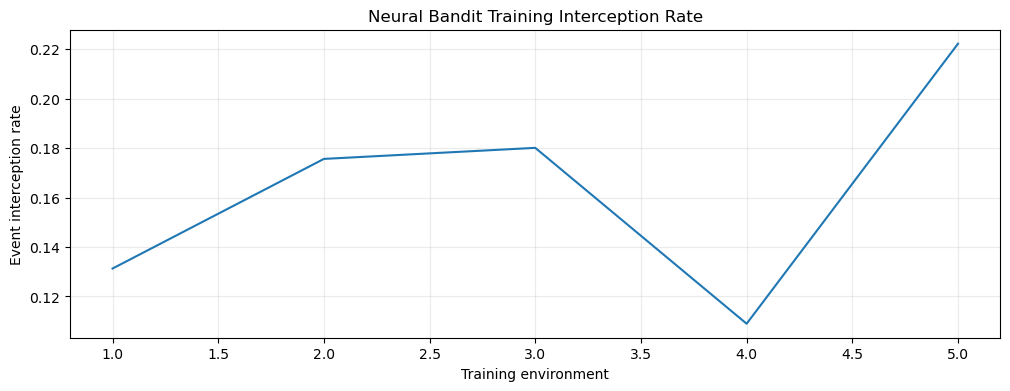

In [23]:

# ============================================================
# 35. OPTIONAL TRAINING CURVE
# ============================================================

if training_history:

    episodes = np.asarray([
        x["episode"]
        for x in training_history
    ])

    isr = np.asarray([
        x["interception_rate"]
        for x in training_history
    ])

    plt.figure(
        figsize=(12, 4)
    )

    plt.plot(
        episodes,
        isr
    )

    plt.xlabel(
        "Training environment"
    )

    plt.ylabel(
        "Event interception rate"
    )

    plt.title(
        "Neural Bandit Training Interception Rate"
    )

    plt.grid(
        True,
        alpha=0.25
    )

    plt.show()



# 36. Final evaluation interface

For final evaluation the policy is frozen:

```text
training=False
```

Therefore:
- no gradient updates,
- no replay updates,
- no Oracle labels during action selection.

The Oracle is used afterward only to calculate the upper-bound comparison.


In [24]:

# ============================================================
# 37. FINAL EVALUATION HELPERS
# ============================================================

def extract_policy_metrics(
    result
):

    return {
        "total_events":
            result[
                "total_event_count"
            ],

        "intercepted_events":
            result[
                "intercepted_event_count"
            ],

        "missed_events":
            len(
                result[
                    "missed_events"
                ]
            ),

        "interception_rate":
            result[
                "event_interception_rate"
            ],

        "mean_delay_s":
            result[
                "mean_intercept_delay_s"
            ],

        "total_delay_s":
            result[
                "total_intercept_delay_s"
            ],

        "unique_bands":
            result[
                "unique_bands_found"
            ],
    }


def evaluate_policy(
    policy,
    environments
):

    results = []

    for path in environments:

        env = np.load(
            path
        ).astype(np.float32)

        result = run_policy_on_environment(
            env=env,
            policy=policy,
            belief_provider=belief_provider,
            reward_function=None,
            training=False,
        )

        metrics = extract_policy_metrics(
            result
        )

        metrics["environment"] = (
            path.name
        )

        results.append({
            "path": path,
            "result": result,
            "metrics": metrics,
        })

    return results


In [25]:

# ============================================================
# 38. ROBUST ORACLE EVENT INTERCEPTIONS
# ============================================================

def oracle_event_interceptions(
    env,
    oracle_schedule
):
    """
    Reconstruct event-level Oracle interceptions.

    The Oracle schedule is evaluated only over the timesteps for
    which both the environment and schedule exist.

    A longer Oracle file therefore cannot cause an IndexError.
    """

    env = np.asarray(
        env,
        dtype=np.float32
    )

    schedule = np.asarray(
        oracle_schedule,
        dtype=np.int64
    ).reshape(-1)

    events = extract_transmission_events(
        env
    )

    event_by_id = {
        event["id"]: event
        for event in events
    }

    active_events = build_event_lookup(
        events,
        len(env)
    )

    evaluation_steps = min(
        len(env),
        len(schedule)
    )

    intercepted_ids = set()
    interception_times = {}

    for t in range(
        evaluation_steps
    ):

        band = int(
            schedule[t]
        )

        if band < 0:
            continue

        if band >= N_FREQ_BINS:
            continue

        for event_id in active_events[t]:

            if event_id in intercepted_ids:
                continue

            event = event_by_id[
                event_id
            ]

            if event["band"] == band:

                intercepted_ids.add(
                    event_id
                )

                interception_times[
                    event_id
                ] = t

    intercepted = {}

    for event_id, t in (
        interception_times.items()
    ):

        event = event_by_id[
            event_id
        ]

        delay_steps = (
            t - event["start"]
        )

        intercepted[event_id] = {
            **event,

            "interception_time":
                t,

            "delay_steps":
                delay_steps,

            "delay_s":
                delay_steps * TIME_BIN_S,
        }

    return intercepted


def compare_to_oracle(
    env,
    environment_name,
    policy_result,
    oracle_dir
):
    """
    Compare the frozen policy with the saved Oracle.

    IMPORTANT:
        The policy result is generated before this function is
        called. The Oracle therefore cannot influence action
        selection.

    Metrics:
        policy_isr:
            policy intercepted events / all environment events.

        oracle_isr:
            Oracle intercepted events / all environment events.

        capture_vs_oracle:
            policy intercepted / Oracle intercepted.

        common-event delay:
            compare delay only for events intercepted by both.
    """

    env = np.asarray(
        env,
        dtype=np.float32
    )

    oracle_schedule = (
        load_oracle_schedule(
            environment_name,
            oracle_dir
         )
    )

    schedule_length = len(
        oracle_schedule
    )

    if schedule_length != len(env):

        print(
            f"WARNING: {environment_name}: "
            f"environment has {len(env)} steps, "
            f"Oracle has {schedule_length} steps. "
            f"Evaluating the first "
            f"{min(len(env), schedule_length)} steps."
        )

    oracle_events = (
        oracle_event_interceptions(
            env,
            oracle_schedule
        )
    )

    policy_events = {
        event["id"]: event
        for event in policy_result[
            "intercepted_events"
        ]
    }

    total_events = len(
        extract_transmission_events(env)
    )

    policy_intercepted = len(
        policy_events
    )

    oracle_intercepted = len(
        oracle_events
    )

    policy_isr = (
        policy_intercepted / total_events
        if total_events > 0
        else np.nan
    )

    oracle_isr = (
        oracle_intercepted / total_events
        if total_events > 0
        else np.nan
    )

    capture_vs_oracle = (
        policy_intercepted
        / oracle_intercepted
        if oracle_intercepted > 0
        else np.nan
    )

    common_ids = (
        set(policy_events)
        &
        set(oracle_events)
    )

    if common_ids:

        policy_delays = np.asarray([
            policy_events[i]["delay_s"]
            for i in common_ids
        ])

        oracle_delays = np.asarray([
            oracle_events[i]["delay_s"]
            for i in common_ids
        ])

        policy_common_delay = float(
            np.mean(policy_delays)
        )

        oracle_common_delay = float(
            np.mean(oracle_delays)
        )

        excess_delay = float(
            policy_common_delay
            - oracle_common_delay
        )

        delay_overhead_pct = (
            excess_delay
            / oracle_common_delay
            * 100.0
            if oracle_common_delay > 0
            else np.nan
        )

    else:

        policy_common_delay = np.nan
        oracle_common_delay = np.nan
        excess_delay = np.nan
        delay_overhead_pct = np.nan

    return {
        "environment":
            environment_name,

        "total_events":
            total_events,

        "policy_intercepted":
            policy_intercepted,

        "oracle_intercepted":
            oracle_intercepted,

        "policy_isr":
            policy_isr,

        "oracle_isr":
            oracle_isr,

        "capture_vs_oracle":
            capture_vs_oracle,

        "common_events":
            len(common_ids),

        "policy_common_mean_delay_s":
            policy_common_delay,

        "oracle_common_mean_delay_s":
            oracle_common_delay,

        "mean_excess_delay_s":
            excess_delay,

        "delay_overhead_pct":
            delay_overhead_pct,

        "oracle_schedule_length":
            schedule_length,

        "environment_length":
            len(env),
    }



# 39. What counts as a real comparison?

The training numbers above are **not** the final performance result.

We now evaluate the frozen neural scheduler on held-out validation environments and run two simple baselines on the **same exact environments**:

- Random scan
- Greedy scan using the current recursive belief

This makes the comparison fair.

The key number is:

\[
ISR = \frac{\text{intercepted transmission events}}
           {\text{total transmission events}}
\]

We also report:
- mean interception delay,
- Oracle ISR,
- neural capture as a fraction of Oracle capture,
- number of validation environments.

Do not compare the neural scheduler's `mean_reward` directly with recursive-model BCE. They measure completely different things.


In [26]:

# ============================================================
# 40. VALIDATION POLICIES + AGGREGATE METRICS
# ============================================================

class RandomScanPolicy:

    def __init__(
        self,
        n_bands=N_FREQ_BINS,
        seed=123
    ):

        self.n_bands = n_bands
        self.rng = np.random.default_rng(
            seed
        )

    def reset_episode(
        self,
        collect=False
    ):

        pass

    def select_action(
        self,
        belief
    ):

        return int(
            self.rng.integers(
                0,
                self.n_bands
            )
        )

    def update(
        self,
        action,
        observation,
        reward
    ):

        pass

    def reward_context(
        self,
        action
    ):

        return {
            "age": MAX_SCAN_GAP_STEPS
        }


class GreedyBeliefPolicy:

    def reset_episode(
        self,
        collect=False
    ):

        pass

    def select_action(
        self,
        belief
    ):

        return int(
            np.argmax(
                np.asarray(
                    belief
                )
            )
        )

    def update(
        self,
        action,
        observation,
        reward
    ):

        pass

    def reward_context(
        self,
        action
    ):

        return {
            "age": MAX_SCAN_GAP_STEPS
        }


def evaluate_policy_on_validation(
    policy,
    environments
):

    results = []

    for path in environments:

        env = np.load(
            path
        ).astype(np.float32)

        result = run_policy_on_environment(
            env=env,
            policy=policy,
            belief_provider=belief_provider,
            reward_function=None,
            training=False,
        )

        results.append({
            "path": path,
            "result": result,
            "metrics":
                extract_policy_metrics(
                    result
                )
        })

    return results


def aggregate_policy_results(
    results
):

    total_events = int(
        sum(
            item["metrics"]["total_events"]
            for item in results
        )
    )

    total_intercepted = int(
        sum(
            item["metrics"][
                "intercepted_events"
            ]
            for item in results
        )
    )

    all_delays = []

    for item in results:

        all_delays.extend([
            event["delay_s"]
            for event in item["result"][
                "intercepted_events"
            ]
        ])

    return {
        "environments":
            len(results),

        "total_events":
            total_events,

        "total_intercepted":
            total_intercepted,

        "micro_isr":
            (
                total_intercepted
                / total_events
                if total_events > 0
                else np.nan
            ),

        "mean_environment_isr":
            float(
                np.nanmean([
                    item["metrics"][
                        "interception_rate"
                    ]
                    for item in results
                ])
            )
            if results
            else np.nan,

        "mean_intercept_delay_s":
            (
                float(np.mean(all_delays))
                if all_delays
                else np.nan
            ),

        "unique_bands_mean":
            float(
                np.mean([
                    item["metrics"][
                        "unique_bands"
                    ]
                    for item in results
                ])
            )
            if results
            else np.nan,
    }


def print_comparison_table(
    validation_files,
    neural_results
):

    random_results = (
        evaluate_policy_on_validation(
            RandomScanPolicy(
                seed=SEED
            ),
            validation_files
        )
    )

    greedy_results = (
        evaluate_policy_on_validation(
            GreedyBeliefPolicy(),
            validation_files
        )
    )

    neural_agg = aggregate_policy_results(
        neural_results
    )

    random_agg = aggregate_policy_results(
        random_results
    )

    greedy_agg = aggregate_policy_results(
        greedy_results
    )

    print(
        "\n"
        + "=" * 78
    )

    print(
        "FROZEN VALIDATION COMPARISON"
    )

    print(
        "=" * 78
    )

    print(
        f"{'Policy':<20}"
        f"{'Micro ISR':>14}"
        f"{'Mean delay(s)':>18}"
        f"{'Environments':>14}"
    )

    print(
        "-" * 78
    )

    for name, metrics in [
        ("Random", random_agg),
        ("Greedy belief", greedy_agg),
        ("Neural Thompson", neural_agg),
    ]:

        print(
            f"{name:<20}"
            f"{metrics['micro_isr']:>13.2%}"
            f"{metrics['mean_intercept_delay_s']:>18.4f}"
            f"{metrics['environments']:>14}"
        )

    return {
        "random": random_results,
        "greedy": greedy_results,
        "neural": neural_results,
        "aggregates": {
            "random": random_agg,
            "greedy": greedy_agg,
            "neural": neural_agg,
        }
    }


In [28]:
# ============================================================
# 41. RUN FROZEN VALIDATION
# ============================================================

val_files = list_rf_environments(
    VAL_RFENV_DIR
)

print(
    f"Found {len(val_files)} validation environments."
)

# ------------------------------------------------------------
# Load trained neural bandit checkpoint
# ------------------------------------------------------------

if BANDIT_CHECKPOINT_PATH.exists():

    checkpoint = neural_bandit_policy.load(
        BANDIT_CHECKPOINT_PATH
    )

    print("✓ Loaded trained neural bandit:")
    print(BANDIT_CHECKPOINT_PATH.resolve())

else:

    print(
        "WARNING: no neural bandit checkpoint found. "
        "Using current in-memory neural bandit."
    )

# ------------------------------------------------------------
# Evaluate Neural Thompson on validation
# ------------------------------------------------------------

final_results = evaluate_policy_on_validation(
    policy=neural_bandit_policy,
    environments=val_files
)

if not final_results:

    raise RuntimeError(
        "No validation results were produced."
    )

verify_online_result(
    final_results[0]["result"]
)

# ------------------------------------------------------------
# Compare Neural vs Random vs Greedy
# ------------------------------------------------------------

comparison = print_comparison_table(
    validation_files=val_files,
    neural_results=final_results
)

# ------------------------------------------------------------
# Oracle comparison
#
# IMPORTANT:
# Oracle is accessed ONLY now, after the neural
# validation episodes have completely finished.
# ------------------------------------------------------------

oracle_comparisons = []

for item in final_results:

    env = np.load(
        item["path"]
    ).astype(np.float32)

    comparison_result = compare_to_oracle(
        env=env,
        environment_name=item["path"].name,
        policy_result=item["result"],
        oracle_dir=VAL_ORACLE_DIR
    )

    oracle_comparisons.append(
        comparison_result
    )

# ------------------------------------------------------------
# Aggregate results
# ------------------------------------------------------------

neural_aggregate = (
    comparison["aggregates"]["neural"]
)

total_oracle_events = int(
    sum(
        x["oracle_intercepted"]
        for x in oracle_comparisons
    )
)

total_policy_events = int(
    sum(
        x["policy_intercepted"]
        for x in oracle_comparisons
    )
)

total_events = int(
    sum(
        x["total_events"]
        for x in oracle_comparisons
    )
)

# Calculate percentages BEFORE formatting them.
# This avoids Python 3.10 multiline f-string issues.

if total_events > 0:

    oracle_micro_isr = (
        total_oracle_events
        / total_events
    )

else:

    oracle_micro_isr = np.nan


if total_oracle_events > 0:

    neural_vs_oracle = (
        total_policy_events
        / total_oracle_events
    )

else:

    neural_vs_oracle = np.nan


# ------------------------------------------------------------
# Print final results
# ------------------------------------------------------------

print(
    "\n"
    + "=" * 78
)

print(
    "ORACLE COMPARISON"
)

print(
    "=" * 78
)

print(
    f"Neural micro ISR      : "
    f"{neural_aggregate['micro_isr']:.2%}"
)

print(
    f"Oracle micro ISR      : "
    f"{oracle_micro_isr:.2%}"
)

print(
    f"Neural / Oracle       : "
    f"{neural_vs_oracle:.2%}"
)

print(
    f"Neural mean delay     : "
    f"{neural_aggregate['mean_intercept_delay_s']:.4f} s"
)

print(
    f"Validation environments: "
    f"{len(val_files)}"
)

Found 4 validation environments.
✓ Loaded trained neural bandit:
C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\neural_oracle_bandit.pt


✓ Online trajectory passed sanity checks.

FROZEN VALIDATION COMPARISON
Policy                   Micro ISR     Mean delay(s)  Environments
------------------------------------------------------------------------------
Random                     12.60%            0.6513             4
Greedy belief               0.79%            0.0000             4
Neural Thompson            15.49%            0.3752             4

ORACLE COMPARISON
Neural micro ISR      : 15.49%
Oracle micro ISR      : 88.65%
Neural / Oracle       : 17.47%
Neural mean delay     : 0.3752 s
Validation environments: 4



# 42. Interpretation

There are now three separate levels of evidence.

### Level 1 — Recursive belief model

Earlier we measured:

- Baseline BCE: **0.282096**
- Recursive BCE: **0.280303**
- Improvement: **0.64%**

That establishes that the recursive updater is slightly better at predicting the next RF state under the random-scan training setup.

It does **not** establish scheduler performance.

### Level 2 — Neural bandit training

The run shown above has only **5 training environments**.

Observed:

- recent ISR: **16.36%**
- recent mean reward: **0.2687**
- bandit loss: **0.149410**
- Oracle loss: **3.158986**
- replay samples: **3043**

These are useful debugging signals, but they are **not enough evidence of generalization**.

In particular, the falling/oscillating ISR over five environments is not a meaningful learning curve yet. Five points is basically a statistical shrug wearing a graph costume.

### Level 3 — Held-out validation

This is the result we actually care about.

Compare:

```text
Random scan
Greedy belief
Neural Thompson scheduler
Oracle reference
```

on the same validation environments.

The neural scheduler should eventually demonstrate:

1. higher event interception rate than Random,
2. higher event interception rate than Greedy,
3. lower interception delay where possible,
4. a substantial fraction of Oracle interception performance.

Only after that should we call the scheduler successful.

### Dataset split

The supplied dataset documentation describes separate training, validation, and test sets, with 2,500 training, 250 validation, and 250 test pulse trains per receiver mode. The RF environments currently present in the project are a much smaller working subset, so the current five-environment run should be treated as a **development experiment**, not the final result.

The problem statement explicitly makes high interception rate and low intercept time primary scheduler objectives, so the validation ISR/delay comparison is the correct next checkpoint.
